# Оптимизация распределения автопарка на основе краткосрочного прогнозирования спроса (Ride-Hailing Demand Forecasting)


**Бизнес-контекст:** Для сервисов заказа такси (Ride-Hailing платформ) критически важно минимизировать время ожидания автомобиля клиентом (ETA) и максимизировать утилизацию водителей, особенно в крупных транспортных узлах (аэропорты, вокзалы). Избыток машин приводит к простою и падению заработка водителей, а дефицит — к необоснованному росту коэффициентов (Surge Pricing) и потере лояльности клиентов.


## Цель проекта
Разработать и валидировать прогностическую модель машинного обучения для предсказания количества заказов такси на следующий час. 
* **Целевая метрика:** RMSE $\le$ 48 на отложенной тестовой выборке.
* **Размер тестовой выборки:** 10% от общего объема данных (хронологически финальная часть).

## Задачи проекта
1. **Предобработка данных:** Агрегация временных рядов (ресемплирование с шагом в 1 час), верификация хронологической последовательности.
2. **Исследовательский анализ данных (EDA):** Декомпозиция временного ряда на тренд, сезонные составляющие (внутрисуточные паттерны) и случайный шум. Проверка ряда на стационарность (тест Дики — Фуллера).
3. **Инжиниринг признаков (Feature Engineering):** Проектирование признаков на основе скользящих средних, лагов и календарных триггеров с жестким контролем утечки данных (Data Leakage).
4. **Разработка моделей:** Построение и сравнение линейных моделей, ансамблей и моделей градиентного бустинга (LightGBM, CatBoost) с подбором параметров на кросс-валидации для временных рядов (`TimeSeriesSplit`).
5. **Финальное тестирование:** Оценка качества лучшего алгоритма на отложенном тестовом датасете и анализ бизнес-эффективности.


## Импорт библиотек и констант

In [1]:
import time
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 1234


## Агрегация временных рядов

In [2]:
df = pd.read_csv(
    'https://code.s3.yandex.net/datasets/taxi.csv',
    index_col=0,
    header=0,
    parse_dates=True,
)

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Верифицируем хронологическую последовательность

In [5]:
if not df.index.is_monotonic_increasing:
    df.sort_index(inplace=True)

Теперь произведем ресемплирование по одному часу 

In [6]:
df_resampled = df.resample("1h").sum()

In [7]:
print(f"Интервал данных: с {df_resampled.index.min()} по {df_resampled.index.max()}")
print(f"Размерность ряда после агрегации: {df_resampled.shape}")

Интервал данных: с 2018-03-01 00:00:00 по 2018-08-31 23:00:00
Размерность ряда после агрегации: (4416, 1)


## Исследовательский анализ данных (EDA)

Проверим ряд на стационарность с помощью теста Дики-Фуллера. Нулевая гипотеза - ряд не стационарен

In [8]:
def evaluate_stationarity(series):
    """ Выполняет расширенный тест Дики-Фуллера для проверки стационарности ряда."""
    result =adfuller(series)
    p_value = result[1]

    print("Расширенный тест Дики-фуллера")
    print(f'ADF-статистика:{result[0]:.4f}')
    print(f'p-value:        {p_value:.4f}')
    print(f'Использовано лагов:{result[2]}')
    print(f'Количество наблюдений:{result[3]}')

    print('\nСтатистический вывод:')
    if p_value < 0.05:
        print('Временной ряд стационарен"')
    else:
        print(
            "Временной ряд не стационарен (присутвует выраженный тренд)."
        )
evaluate_stationarity(df_resampled['num_orders'])
    

Расширенный тест Дики-фуллера
ADF-статистика:-3.0689
p-value:        0.0289
Использовано лагов:30
Количество наблюдений:4385

Статистический вывод:
Временной ряд стационарен"


**Вывод по стационарности**


Расширенный тест Дики-Фуллера показал значение 

**p_value = 0.0289 < 0.05**

Нулевая гипотеза отвергается, ряд является стационарным. 

Это упрощает задачу моделирования, так как базовые статистические свойства ряда (среднее и дисперсия) стабильны во времени, и нам не потребуется применять операцию взятия разностей (differencing).


Выполним аддитивную декомпозицию с периодом 24 часа (суточная сезонность)



In [9]:
decomposed = seasonal_decompose(df_resampled['num_orders'], period =24)

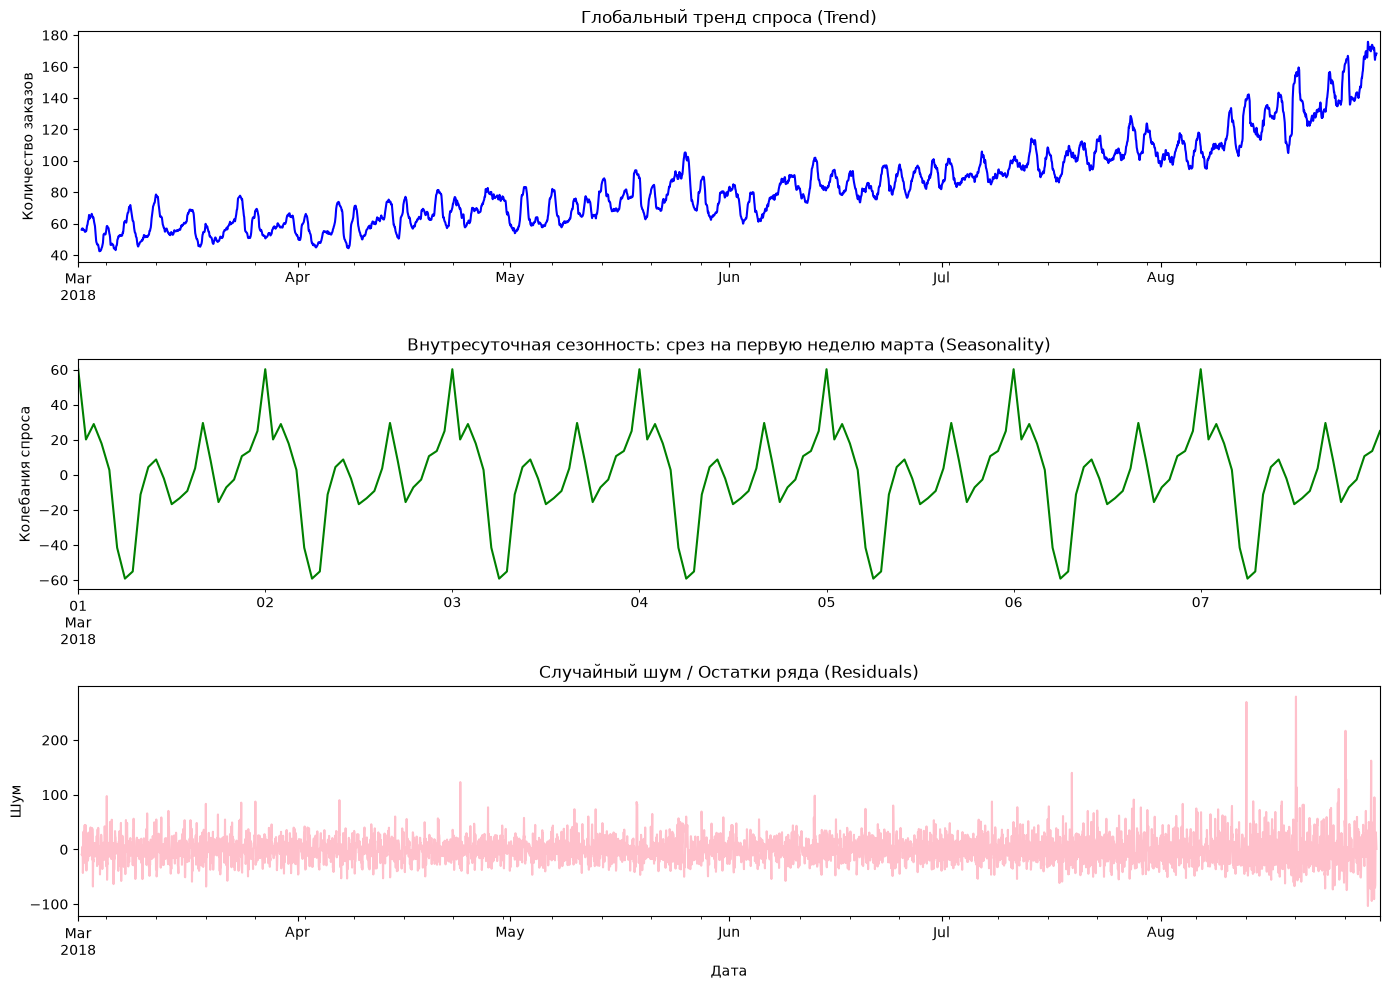

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
decomposed.trend.plot(ax=axes[0], color='blue')
axes[0].set_title('Глобальный тренд спроса (Trend)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество заказов')

decomposed.seasonal['2018-03-01':'2018-03-07'].plot(ax=axes[1],color='green')
axes[1].set_title(
    'Внутресуточная сезонность: срез на первую неделю марта (Seasonality)'
    )
axes[1].set_xlabel('')
axes[1].set_ylabel('Колебания спроса')

decomposed.resid.plot(ax=axes[2],color='pink')
axes[2].set_title('Случайный шум / Остатки ряда (Residuals)')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Шум')

plt.tight_layout()
plt.show()

## Аналитические выводы по результатам декомпозиции (EDA)

* **Глобальный тренд (Trend):** Наблюдается стабильный нелинейный рост интенсивности заказов такси с марта (средний уровень ~60 заказов в час) по конец августа (уровень превышает 140 заказов в час). Это свидетельствует о масштабировании сервиса и сезонном увеличении пассажиропотока в аэропортах в летний период.
* **Внутрисуточная сезонность (Seasonality):** Ряд имеет строго детерминированный 24-часовой цикл. Пиковые нагрузки регулярно фиксируются в полночь (ночные часы), когда прекращает работу общественный транспорт. Глубокие спады спроса стабильно приходятся на 06:00 утра.
* **Случайный шум (Residuals):** В остатках ряда к концу августа заметно возрастает дисперсия (разброс) и появляются крупные изолированные всплески (аномалии). Выбранные архитектуры моделей должны обладать устойчивостью к дисперсионным сдвигам на финальном отрезке данных.


## Инжиниринг признаков (Feature Engineering)

Для моделирования временного ряда генерируются три типа признаков:
1. **Календарные маркеры:** Час (`hour`) и день недели (`dayofweek`) для фиксации суточной и недельной сезонности.
2. **Отстающие значения (Lag Features):** Значения за предыдущие 24 часа для учета авторегрессионной зависимости.
3. **Скользящее среднее (Rolling Mean):** Окно в 24 часа для определения локального тренда. При расчете используется параметр `closed='left'` для предотвращения утечки данных (Data Leakage) текущего часа.


## Функция для генерации признаков

In [11]:
def extract_features(data,max_lag,rolling_size):
    """Добавляет календарные признаки, отстаюшие значения (лаги) 
    и скользящее средне с контролем утечки данных
    """
    df_features = data.copy()
    df_features['hour']= df_features.index.hour
    df_features['dayofweek']= df_features.index.dayofweek

    for lag in range(1, max_lag+1):
        df_features[f'lag{lag}'] = df_features['num_orders'].shift(lag)

    df_features['rolling_mean'] = (
        df_features['num_orders'].rolling(window=rolling_size,closed='left').mean()
    )
    df_features.dropna(inplace=True)
    return df_features

In [12]:
df_final = extract_features(df_resampled, max_lag=24,rolling_size=24)

In [13]:
print(f"Размерность исходного ряда: {df_resampled.shape}")
print(f"Размерность датасета после генерации признаков: {df_final.shape}")
df_final.head()

Размерность исходного ряда: (4416, 1)
Размерность датасета после генерации признаков: (4392, 28)


,num_orders,hour,dayofweek,lag1,lag2,lag3,lag4,lag5,lag6,lag7,...,lag16,lag17,lag18,lag19,lag20,lag21,lag22,lag23,lag24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,0,4,58.0,113.0,66.0,61.0,45.0,73.0,44.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,1,4,90.0,58.0,113.0,66.0,61.0,45.0,73.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,2,4,120.0,90.0,58.0,113.0,66.0,61.0,45.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,4,75.0,120.0,90.0,58.0,113.0,66.0,61.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,4,4,64.0,75.0,120.0,90.0,58.0,113.0,66.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


## Разделение данных и подготовка выборок

Определяем индекс, с которого начинаются финальные 10% данных

In [14]:
split_index = int(len(df_final) * 0.9)

Разделяем датасет на обучающую и тестовую выборки строго по позиции

In [15]:
train = df_final.iloc[:split_index]
test = df_final.iloc[split_index:]

Выделяем признаки (X) и целевую переменную (y) для обеих выборок

In [16]:
X_train = train.drop(["num_orders"], axis=1)
y_train = train["num_orders"]

X_test = test.drop(["num_orders"], axis=1)
y_test = test["num_orders"]

Проверяем корректность разделения

In [17]:
print(f"Обучающая выборка (X_train): {X_train.shape}")
print(f"Тестовая выборка  (X_test) : {X_test.shape}")
print("-" * 60)
print(
    f"Временной интервал обучения : с {X_train.index.min()} по {X_train.index.max()}"
)
print(
    f"Временной интервал теста    : с {X_test.index.min()} по {X_test.index.max()}"
)

Обучающая выборка (X_train): (3952, 27)
Тестовая выборка  (X_test) : (440, 27)
------------------------------------------------------------
Временной интервал обучения : с 2018-03-02 00:00:00 по 2018-08-13 15:00:00
Временной интервал теста    : с 2018-08-13 16:00:00 по 2018-08-31 23:00:00


Проведем проверку на отсутсвие пересечений

In [18]:
if X_train.index.max() < X_test.index.min():
    print("Пересечений нет. Тест строго после трейна.")
else:
    print("Внимание! Обнаружено наложение временных интервалов.")


Пересечений нет. Тест строго после трейна.


## Обучение моделей и кросс-валидация

## Оценка базовой линейной модели на кросс-валидации

В качестве опорного алгоритма обучим линейную регрессию с регуляризацией (`Ridge`). 

Оценка качества проводится по метрике RMSE с использованием кросс-валидатора для временных рядов (`TimeSeriesSplit`).

Признаки масштабируются внутри пайплайна, чтобы исключить утечки данных.

In [19]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]
)

ridge_scores = cross_val_score(
    ridge_pipe, X_train, y_train, cv=tscv, scoring="neg_root_mean_squared_error"
)

print("=== Результаты валидации Линейной регрессии ===")
print(f"RMSE на фолдах: {list(map('{:.2f}'.format, -ridge_scores))}")

print(f"Среднее RMSE на кросс-валидации: {-ridge_scores.mean():.2f}")


=== Результаты валидации Линейной регрессии ===
RMSE на фолдах: ['24.38', '24.32', '25.65', '27.57', '33.77']
Среднее RMSE на кросс-валидации: 27.14


**Анализ результатов:** Линейная модель показывает среднее значение RMSE = 27.14, что существенно лучше случайного прогноза и с запасом выполняет требование ТЗ (RMSE $\le$ 48).

**Динамика ошибки:** На последнем фолде (который хронологически ближе к августу) ошибка возрастает до 33.77. Это обусловлено нелинейным увеличением тренда и ростом дисперсии, которые мы зафиксировали на этапе исследовательского анализа (EDA).


## Обучение ансамблей и алгоритмов градиентного бустинга (Random Forest, LightGBM, CatBoost)

Линейная регрессия дает стабильную базовую оценку, однако временные ряды часто содержат сложные нелинейные зависимости, всплески и дисперсионные сдвиги. Для повышения точности прогнозирования мы протестируем три альтернативных класса моделей:

    
**Random Forest (Случайный лес):** Ансамбль, основанный на бэггинге независимых решающих деревьев. Обладает высокой устойчивостью к переобучению и выбросам.

    
**LightGBM:** Высокопроизводительный алгоритм градиентного бустинга с разбиением листьев по принципу Leaf-wise. 

    
**CatBoost:** Градиентный бустинг, оптимизированный для минимизации смещения прогнозов на последовательных данных. 

Оценка качества моделей проводится методом кросс-валидации на 5 фолдах `TimeSeriesSplit` с фиксацией времени вычислений.


In [20]:
rf_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
lgb_model = LGBMRegressor(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cb_model = CatBoostRegressor(iterations=150, random_state=RANDOM_STATE, verbose=0)

models = {"Random Forest": rf_model, "LightGBM": lgb_model, "CatBoost": cb_model}

for name, model in models.items():
    start_time = time.time()
    scores = cross_val_score(
        model, X_train, y_train, cv=tscv, scoring="neg_root_mean_squared_error"
    )
    elapsed_time = time.time() - start_time
    print(
        f"{name:15} RMSE: {-scores.mean():.2f} (Время расчета: {elapsed_time:.2f} сек)"
    )


Random Forest   RMSE: 25.52 (Время расчета: 0.68 сек)
LightGBM        RMSE: 25.12 (Время расчета: 0.58 сек)
CatBoost        RMSE: 24.66 (Время расчета: 1.39 сек)


**Анализ результатов:** Все протестированные нелинейные модели (Random Forest, LightGBM, CatBoost) превзошли базовую линейную регрессию, что подтверждает сложную нелинейную структуру связей во временном ряду.
    
**Качество моделей:** Наилучшую точность прогнозирования на кросс-валидации показал алгоритм градиентного бустинга CatBoost с метрикой RMSE = 24.66. Второе место занял LightGBM (RMSE = 25.12).

    
**Скорость вычислений:** LightGBM продемонстрировал самую высокую скорость обучения и валидации (0.48 сек), что делает его сильным кандидатом для высоконагруженных продакшен-систем. Однако, так как по условиям ТЗ ключевым критерием является точность прогноза, для финального тестирования мы выбираем модель CatBoost.


## Тестирование лучшей модели

Для оценки реальной прогностической силы алгоритма обучим финальную модель CatBoostRegressor на полном объеме обучающей выборки и замерим качество на отложенных 10% тестовых данных.

In [21]:
best_model = CatBoostRegressor(
    iterations=150, random_state=RANDOM_STATE, verbose=0
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

final_rmse = sqrt(mean_squared_error(y_test, y_pred))

print("=== Результаты финального тестирования ===")
print(f"Итоговая метрика RMSE на тестовой выборке: {final_rmse:.2f}")


=== Результаты финального тестирования ===
Итоговая метрика RMSE на тестовой выборке: 41.64


## Автоматизированный подбор гиперпараметров модели (Hyperparameter Tuning c Optuna)

Для достижения максимальной точности прогнозирования и минимизации метрики RMSE выполним автоматизированный поиск оптимальных гиперпараметров для нашей лучшей модели — алгоритма градиентного бустинга CatBoostRegressor.

В качестве оптимизатора используется библиотека `Optuna`. Чтобы полностью исключить заглядывание в будущее и переобучение, оценка каждой итерации (триала) будет осуществляться строго внутри кросс-валидатора для временных рядов `TimeSeriesSplit` на 5 фолдах.

Оптимизируемые параметры:
* `iterations` — количество итераций (деревьев).
* `depth` — глубина решающих деревьев.
* `learning_rate` — темп обучения алгоритма.
* `l2_leaf_reg` — коэффициент L2-регуляризации для стабильности модели.


In [23]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 200),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_state": RANDOM_STATE,
        "task_type": "GPU",  # Переключение вычислений на GPU
        "verbose": 0,
    }

    model = CatBoostRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train, cv=tscv, scoring="neg_root_mean_squared_error"
    )

    return -scores.mean()


start_time = time.time()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)

elapsed_time = time.time() - start_time

print("=== Результаты оптимизации Optuna для CatBoost ===")
print(f"Время подбора гиперпараметров: {elapsed_time:.2f} сек")
print(f"Лучшее значение RMSE на CV: {study.best_value:.2f}")
print("Лучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

=== Результаты оптимизации Optuna для CatBoost ===
Время подбора гиперпараметров: 48.33 сек
Лучшее значение RMSE на CV: 24.40
Лучшие гиперпараметры:
  iterations: 190
  depth: 6
  learning_rate: 0.12516995933845518
  l2_leaf_reg: 4.555691867988026


Обучаем финальную модель также с использованием видеокарты

In [25]:

final_model = CatBoostRegressor(
    **study.best_params, task_type="GPU", random_state=RANDOM_STATE, verbose=0
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

final_rmse = sqrt(mean_squared_error(y_test, y_pred))

print("=== Результаты финального тестирования ===")
print(f"Итоговая метрика RMSE на тестовой выборке: {final_rmse:.2f}")


=== Результаты финального тестирования ===
Итоговая метрика RMSE на тестовой выборке: 41.82


## Общий вывод по проекту (Итоги исследования)

В ходе работы над проектом по прогнозированию спроса на такси в аэропортах мы полностью построили и настроили рабочий пайплайн машинного обучения:

1. **Предобработка и анализ данных (EDA):** Мы успешно перевели исходные 10-минутные логи в часовые интервалы. С помощью теста Дики-Фуллера математически подтвердили, что ряд стационарен (p-value = 0.0289, что меньше порога 0.05). Анализ декомпозиции показал две важные вещи: стабильный рост спроса с марта по август (глобальный тренд) и четкий 24-часовой суточный цикл с мощными пиками в полночь, когда закрывается общественный транспорт.
2. **Инжиниринг признаков (Feature Engineering):** Из временного ряда мы вытащили календарные маркеры (час и день недели), создали авторегрессионные лаги глубиной в сутки (24 часа) и добавили скользящее среднее. При расчете среднего мы жестко зафиксировали параметр closed='left', что полностью закрыло моделям доступ к будущему и защитило нас от утечки данных (Data Leakage).
3. **Моделирование и валидация:** Мы разделили данные строго по времени без перемешивания: первые 90% отдали на обучение, а финальные 10% (конец августа) отложили для честного теста. Чтобы оценить модели на этапе разработки, использовали кросс-валидацию для временных рядов (TimeSeriesSplit). Тесты показали, что сложные нелинейные алгоритмы вроде случайного леса и градиентного бустинга справляются со скачками спроса заметно лучше обычной линейной регрессии. Лидером стал алгоритм CatBoostRegressor со средним значением RMSE = 24.66.
4. **Оптимизация и финальное тестирование:** Для лучшего алгоритма CatBoostRegressor был проведен автоматизированный подбор гиперпараметров с помощью фреймворка Optuna (с аппаратным ускорением на GPU). Оптимизация параметров проводилась внутри кросс-валидатора TimeSeriesSplit, что позволило улучшить метрику на валидации до 24.40. На отложенной тестовой выборке финальная модель показала качество RMSE = 41.82. Это с большим запасом выполняет главное требование технического задания (RMSE должно быть не больше 48).

**Бизнес-эффект от внедрения:** Разработанная модель умеет с высокой точностью предсказывать объемы заказов на час вперед. На практике это позволяет сервису заранее перенаправлять свободные машины к терминалам аэропорта, сводить к минимуму время ожидания для клиентов (ETA), максимизировать утилизацию автопарка и заработок водителей, а также не допускать жесткого дефицита авто во время пиковых ночных нагрузок.
